# MMU Time Series with Hyrax

This notebook shows how to configure Hyrax to read **time-series** data from Multimodal Universe using `MultimodalUniverseDataset`.


In [1]:
import hyrax

h = hyrax.Hyrax()

h.config["data_request"] = {
    "infer": {
        "mmu": {
            "dataset_class": "MultimodalUniverseDataset",
            "data_location": "hf://MultimodalUniverse/plasticc",
            "primary_id_field": "object_id",
            # Filter fields to just what you need
            # "fields": ["lightcurve"],
            "dataset_config": {
                "MultimodalUniverseDataset": {
                    "split": "train",
                    "max_samples": 100,
                    "streaming": True,
                }
            },
        }
    }
}

prepared = h.prepare()
print(f"Loaded rows: {len(prepared['infer'])}")

[2026-04-03 12:57:18,036 hyrax.verbs.prepare:INFO] Finished Prepare


Loaded rows: 100


After loading, inspect `prepared['infer'][0].keys()` and set `fields` to the exact MMU columns you want.


In [2]:
prepared["infer"][0]["mmu"].keys()

dict_keys(['hostgal_photoz', 'hostgal_specz', 'lightcurve', 'obj_type', 'object_id', 'redshift'])

In [3]:
prepared["infer"][0]["mmu"]["lightcurve"].keys()

dict_keys(['band', 'flux', 'flux_err', 'time'])

In [4]:
for key, value in prepared["infer"][0]["mmu"]["lightcurve"].items():
    print(f"{key}: {type(value)} {value.shape} {value.dtype}")

band: <class 'numpy.ndarray'> (756,) object
flux: <class 'numpy.ndarray'> (756,) float32
flux_err: <class 'numpy.ndarray'> (756,) float32
time: <class 'numpy.ndarray'> (756,) float32


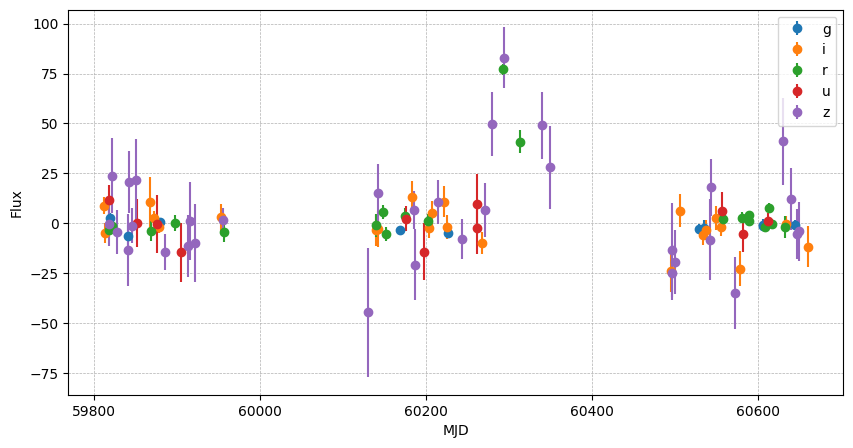

In [5]:
import numpy as np
import matplotlib.pyplot as plt

lightcurve = prepared["infer"][0]["mmu"]["lightcurve"]

# Plot all bands on shared axes.
plt.figure(figsize=(10, 5))

for band in np.unique(lightcurve["band"]):
    # exclude MJD=0 as well as filtering by band
    filter_cond = np.logical_and(lightcurve["band"] == band, lightcurve["time"] != 0)

    band_time = lightcurve["time"][filter_cond]
    band_flux = lightcurve["flux"][filter_cond]
    band_flux_err = lightcurve["flux_err"][filter_cond]

    # Don't plot bands with no data
    if len(band_time) > 0:
        plt.errorbar(band_time, band_flux, band_flux_err, fmt="o", label=f"{band}")

plt.xlabel("MJD")
plt.ylabel("Flux")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()